<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/%20Chapter-4-Nonholonomic-Mechanics/Untitled161.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Neural approximation of the constrained bead dynamics**

We use a Physics-Informed Neural Network (PINN) to approximate the optimal trajectory of the constrained bead on a wire, minimizing the energy
$$E(c)=\frac{1}{2}\int_0^1 \phi'(s)^2 ds$$
 under the constraint $x'(s)=\alpha \phi'(s)$ and fixed endpoints $(\phi_0,x_0)$, $(\phi_1,x_1)$.

  For a given winding number $k \in \mathbb{Z}$, we set $\Delta\phi=\phi_1-\phi_0+2\pi k$ and parametrize

$$
\phi(s)=\phi_0+\Delta\phi\,s+s(1-s)N_\theta(s), \qquad
x(s)=x_0+\alpha(\phi(s)-\phi_0),
$$

where $N_\theta$ is a neural network. The loss combines the energy $\frac{1}{2}\mathbb{E}[\phi'(s)^2]$ (computed via automatic differentiation) with a penalty enforcing $x(1)=x_1$.

 Training with stochastic gradient descent yields convergence to the affine minimizer $\phi(s)=\phi_0+\Delta\phi\,s$, $x(s)=x_0+\alpha\Delta\phi\,s$, illustrating that, once the geometry and constraints are embedded, the network recovers the geodesic by minimizing the energy.

 The loss looks stochastic since it is almost nothing to learn as the solutions are affine and coincide with the initialization.

ep 0: loss=11883.701172, E=2167.455566, BC=1943.249023


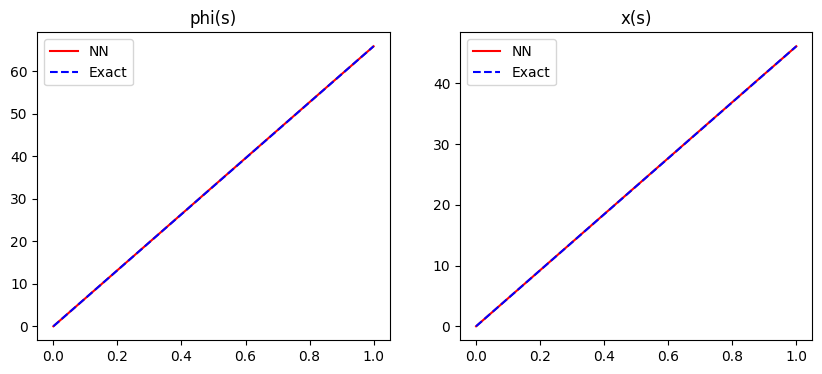

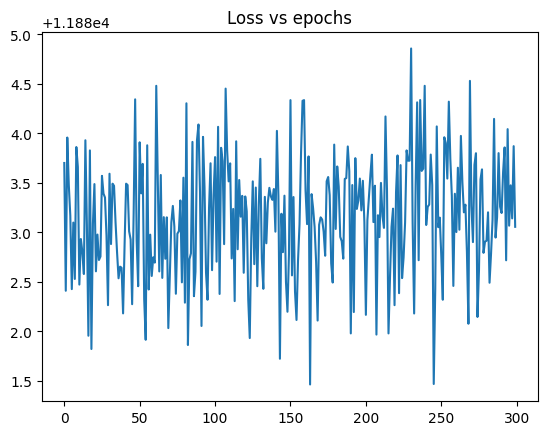

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parameters
# -----------------------
phi0, phi1 = 0.0, 3.0
x0, x1 = 0.0, 2.0
alpha = 0.7
k = 10   # winding number

Delta_phi = phi1 - phi0 + 2*np.pi*k

# -----------------------
# Neural network
# -----------------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='swish'),

    tf.keras.layers.Dense(1)
])

# -----------------------
# Hard embedding
# -----------------------
def phi(s):
    nn = model(s)
    return phi0 + Delta_phi*s + s*(1-s)*nn

def x(s):
    return x0 + alpha*(phi(s) - phi0)

# -----------------------
# Loss
# -----------------------
def loss_fn(s):
    with tf.GradientTape() as tape:
        tape.watch(s)
        phi_s = phi(s)
    phi_s_prime = tape.gradient(phi_s, s)

    energy = 0.5 * tf.reduce_mean(phi_s_prime**2)

    # endpoint constraint
    s1 = tf.ones((1,1))
    x1_pred = x(s1)
    bc = tf.reduce_mean((x1_pred - x1)**2)

    return energy + 5.0 * bc, energy, bc

# -----------------------
# Training
# -----------------------
optimizer = tf.keras.optimizers.Adam(1e-4)

epochs = 300
loss_hist = []

for ep in range(epochs):
    s = tf.random.uniform((128,1))

    with tf.GradientTape() as tape:
        L, E, BC = loss_fn(s)

    grads = tape.gradient(L, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_hist.append(float(L))

    if ep % 500 == 0:
        print(f"ep {ep}: loss={L.numpy():.6f}, E={E.numpy():.6f}, BC={BC.numpy():.6f}")

# -----------------------
# Visualization
# -----------------------
s_plot = np.linspace(0,1,200).reshape(-1,1).astype(np.float32)

phi_pred = phi(s_plot).numpy()
x_pred = x(s_plot).numpy()

# Exact solution
phi_exact = phi0 + Delta_phi * s_plot
x_exact = x0 + alpha * Delta_phi * s_plot

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(s_plot, phi_pred, 'r', label='NN')
plt.plot(s_plot, phi_exact, 'b--', label='Exact')
plt.title("phi(s)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(s_plot, x_pred, 'r', label='NN')
plt.plot(s_plot, x_exact, 'b--', label='Exact')
plt.title("x(s)")
plt.legend()

plt.show()

# Loss curve
plt.plot(loss_hist)
plt.title("Loss vs epochs")
plt.show()

# **Nonholonomic bead dynamics**

Soft constraint of nonholonomic constraint

ep 0: loss=54.231407, energy=0.000788, nonhol=1.084612
ep 500: loss=19.872635, energy=6.301891, nonhol=0.271415
ep 1000: loss=7.592686, energy=7.074609, nonhol=0.010362
ep 1500: loss=7.157900, energy=6.728033, nonhol=0.008597
ep 2000: loss=6.467344, energy=6.223784, nonhol=0.004871
ep 2500: loss=6.160389, energy=5.946938, nonhol=0.004269
ep 3000: loss=6.377100, energy=6.137030, nonhol=0.004801
ep 3500: loss=6.331513, energy=6.075950, nonhol=0.005111


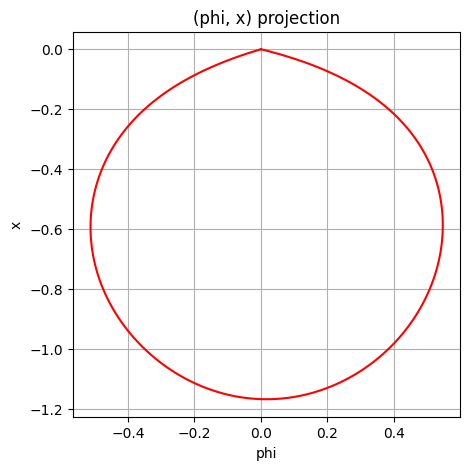

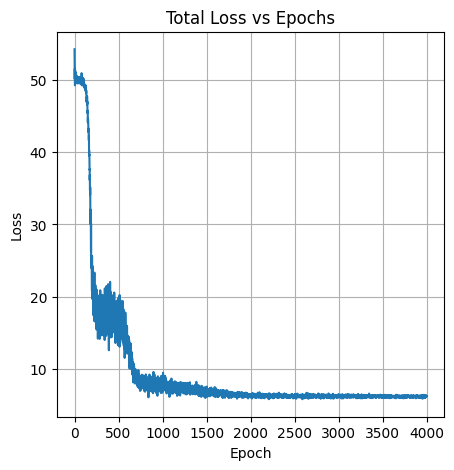

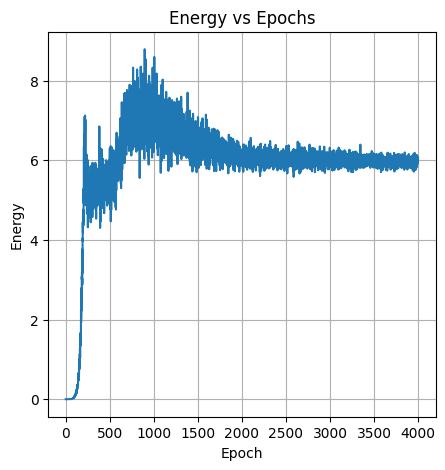

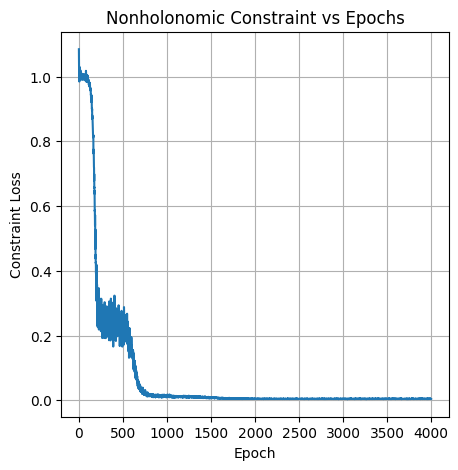

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parameters
# -----------------------
phi0, phi1 = 0.0, 0.0
x0, x1 = 0.0, 0.0
y0, y1 = 0.0, 1.0

k = 0
alpha = 50.0   # penalty weight

# -----------------------
# Neural network
# -----------------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(3)
])

# -----------------------
# Hard embedding of BC
# -----------------------
def forward(t):
    nn = model(t)

    phi = (1-t)*phi0 + t*(phi1 + 2*np.pi*k) + t*(1-t)*nn[:,0:1]
    x   = (1-t)*x0   + t*x1                + t*(1-t)*nn[:,1:2]
    y   = (1-t)*y0   + t*y1                + t*(1-t)*nn[:,2:3]

    return phi, x, y

# -----------------------
# Loss
# -----------------------
def loss_fn(t):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        phi, x, y = forward(t)

    phi_t = tape.gradient(phi, t)
    x_t   = tape.gradient(x, t)
    y_t   = tape.gradient(y, t)

    energy = 0.5 * tf.reduce_mean(phi_t**2 + x_t**2)
    nonhol = tf.reduce_mean((y_t - phi * x_t)**2)

    total = energy + alpha * nonhol

    return total, energy, nonhol

# -----------------------
# Training
# -----------------------
optimizer = tf.keras.optimizers.Adam(5e-4)

epochs = 4000

loss_hist = []
energy_hist = []
nonhol_hist = []

for ep in range(epochs):
    t = tf.random.uniform((128,1))

    with tf.GradientTape() as tape:
        L, E, NH = loss_fn(t)

    grads = tape.gradient(L, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_hist.append(float(L))
    energy_hist.append(float(E))
    nonhol_hist.append(float(NH))

    if ep % 500 == 0:
        print(f"ep {ep}: loss={L.numpy():.6f}, energy={E.numpy():.6f}, nonhol={NH.numpy():.6f}")

# -----------------------
# Visualization
# -----------------------
t_plot = np.linspace(0,1,200).reshape(-1,1).astype(np.float32)

phi_pred, x_pred, y_pred = forward(t_plot)

phi_pred = phi_pred.numpy()
x_pred   = x_pred.numpy()

# (phi, x) projection
plt.figure(figsize=(5,5))
plt.plot(phi_pred, x_pred, 'r')
plt.xlabel("phi")
plt.ylabel("x")
plt.title("(phi, x) projection")
plt.grid()
plt.show()

# -----------------------
# Loss curves
# -----------------------
plt.figure(figsize=(5,5))
plt.plot(loss_hist)
plt.title("Total Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(5,5))
plt.plot(energy_hist)
plt.title("Energy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Energy")
plt.grid()
plt.show()

plt.figure(figsize=(5,5))
plt.plot(nonhol_hist)
plt.title("Nonholonomic Constraint vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Constraint Loss")
plt.grid()
plt.show()

Hard embedding of nonholonomic constraint

ep 0: loss=100.006294, energy=0.007995, bc=0.999983
ep 500: loss=6.858562, energy=6.737366, bc=0.001212
ep 1000: loss=6.427555, energy=6.320299, bc=0.001073
ep 1500: loss=6.346834, energy=6.242374, bc=0.001045
ep 2000: loss=6.255656, energy=6.153695, bc=0.001020
ep 2500: loss=6.221400, energy=6.120589, bc=0.001008


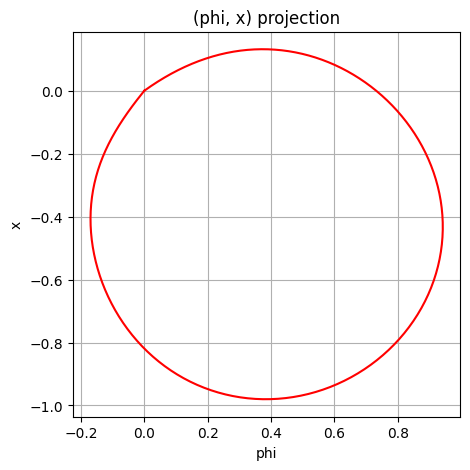

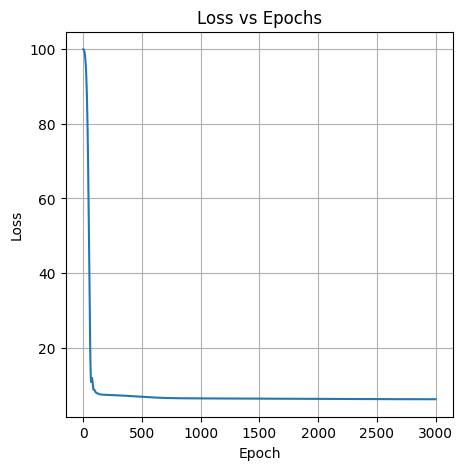

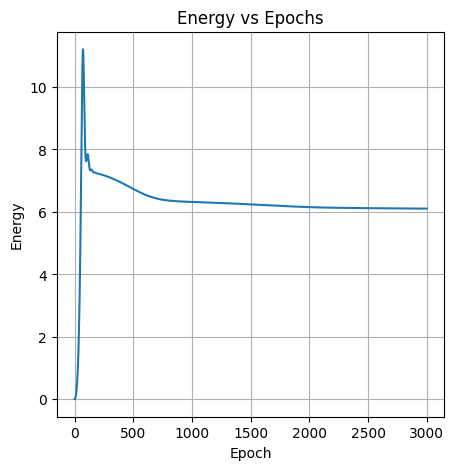

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parameters
# -----------------------
phi0, phi1 = 0.0, 0.0
x0, x1 = 0.0, 0.0
y0, y1 = 0.0, 1.0

k = 0
beta = 100.0   # endpoint penalty

# -----------------------
# Neural network
# -----------------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(2)
])

# -----------------------
# Forward: phi, x
# -----------------------
def phi_x(t):
    nn = model(t)

    phi = (1-t)*phi0 + t*(phi1 + 2*np.pi*k) + t*(1-t)*nn[:,0:1]
    x   = (1-t)*x0   + t*x1                + t*(1-t)*nn[:,1:2]

    return phi, x

# -----------------------
# Compute y via integral
# -----------------------
def compute_y(t):
    with tf.GradientTape() as tape:
        tape.watch(t)
        phi, x = phi_x(t)
    x_t = tape.gradient(x, t)

    integrand = phi * x_t  # φ x'

    # trapezoidal integration
    dt = t[1:] - t[:-1]
    avg = 0.5 * (integrand[1:] + integrand[:-1])

    integral = tf.concat(
        [tf.zeros((1,1)), tf.cumsum(avg * dt)],
        axis=0
    )

    y = y0 + integral
    return phi, x, y

# -----------------------
# Loss function
# -----------------------
def loss_fn(t):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        phi, x = phi_x(t)

    phi_t = tape.gradient(phi, t)
    x_t   = tape.gradient(x, t)

    # Energy (scalar)
    energy = 0.5 * tf.reduce_mean(phi_t**2 + x_t**2)

    # Compute y(t)
    phi_full, x_full, y_full = compute_y(t)

    # Endpoint condition (scalar)
    y_end = y_full[-1]
    bc = tf.reduce_mean((y_end - y1)**2)

    total = energy + beta * bc

    return total, energy, bc

# -----------------------
# Training
# -----------------------
optimizer = tf.keras.optimizers.Adam(1e-3)

epochs = 3000

loss_hist = []
energy_hist = []
bc_hist = []

for ep in range(epochs):

    # Use sorted grid (important for integration)
    t = tf.linspace(0.0, 1.0, 200)[:,None]

    with tf.GradientTape() as tape:
        L, E, BC = loss_fn(t)

    grads = tape.gradient(L, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_hist.append(float(L))
    energy_hist.append(float(E))
    bc_hist.append(float(BC))

    if ep % 500 == 0:
        print(f"ep {ep}: loss={float(L):.6f}, energy={float(E):.6f}, bc={float(BC):.6f}")

# -----------------------
# Visualization
# -----------------------
t_plot = np.linspace(0,1,300).reshape(-1,1).astype(np.float32)

phi_pred, x_pred, y_pred = compute_y(tf.convert_to_tensor(t_plot))

phi_pred = phi_pred.numpy()
x_pred   = x_pred.numpy()

# (phi, x) projection
plt.figure(figsize=(5,5))
plt.plot(phi_pred, x_pred, 'r')
plt.xlabel("phi")
plt.ylabel("x")
plt.title("(phi, x) projection")
plt.grid()
plt.show()

# -----------------------
# Loss plots
# -----------------------
plt.figure(figsize=(5,5))
plt.plot(loss_hist)
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(5,5))
plt.plot(energy_hist)
plt.title("Energy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Energy")
plt.grid()
plt.show()